## Find the best ANN hyper-parameter first, and then run it 100 times

## SHAR

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import joblib
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Convert Xtrain and Xtest back to DataFrames with proper column names
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']  # Define features
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

class ANNModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(ANNModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Randomize ANN hyperparameters for each run
layers = 2  # Number of layers between 2 and 5
neurons = 52  # Number of neurons per layer
learning_rate = 0.00077  # Fixed learning rate

# Create the ANN model
ann_model = ANNModel(input_dim=Xtrain.shape[1], layers=layers, neurons=neurons)
optimizer = optim.Adam(ann_model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Training the model
epochs = 300
for epoch in range(epochs):
    ann_model.train()
    optimizer.zero_grad()
    ytrain_tensor = torch.FloatTensor(ytrain).view(-1, 1)  # Ensure ytrain is a column vector
    ytrain_pred = ann_model(torch.FloatTensor(Xtrain))
    loss = criterion(ytrain_pred, ytrain_tensor)
    loss.backward()
    optimizer.step()

# Perform SHAP analysis
explainer = shap.DeepExplainer(ann_model, torch.FloatTensor(Xtrain))  # Use DeepExplainer for PyTorch models
shap_values = explainer.shap_values(torch.FloatTensor(Xtest))  # Calculate SHAP values for the test data

<class 'numpy.ndarray'>


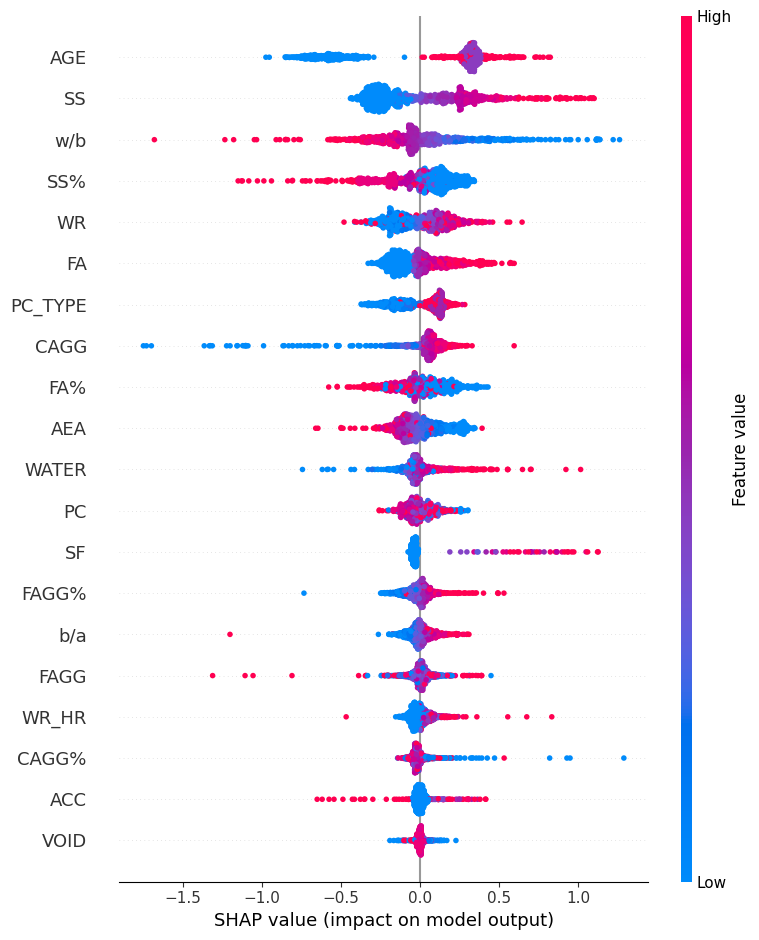

In [6]:
# Check the type of shap_values
print(type(shap_values))  # This will help you understand the structure of the output

# If shap_values is a list or tuple, extract the first element (for regression tasks)
if isinstance(shap_values, list) or isinstance(shap_values, tuple):
    shap_values_np = shap_values[0]  # Assuming the first element contains the relevant SHAP values
else:
    shap_values_np = shap_values  # If it's already a numpy array

# Create summary plot
shap.summary_plot(shap_values_np, Xtest_df, feature_names=features, show=False)

# Save the plot
plt.savefig('shap_summary_plot.png', bbox_inches='tight', dpi=300)  # You can change the filename and format as needed
# plt.close()  # Close the figure to free up memory